In [15]:
import os
os.makedirs("image_classes", exist_ok=True)

In [16]:
%%writefile image_classes/image.py
import numpy as np


class Image:

    def __init__(self, data):
        self.data = data
        self.height = data.shape[0]
        self.width = data.shape[1]

    def info(self):
        print(f"{self.__class__.__name__}: "
              f"{self.width}x{self.height}, dtype={self.data.dtype}")

    def save(self, path):
        import cv2
        cv2.imwrite(path, self.data)


class BinaryImage(Image):
    """Бинарное изображение. Значения 0 или 255."""

    def __init__(self, data):
        data = (data > 0).astype(np.uint8) * 255
        super().__init__(data)


class MonoImage(Image):
    """Монохромное изображение. Значения 0..255."""

    def __init__(self, data):
        data = np.clip(data, 0, 255).astype(np.uint8)
        super().__init__(data)


class ColorImage(Image):
    """Цветное изображение. Три канала по 0..255."""

    def __init__(self, data):
        data = np.clip(data, 0, 255).astype(np.uint8)
        super().__init__(data)

    def info(self):
        print(f"{self.__class__.__name__}: "
              f"{self.width}x{self.height}x3, dtype={self.data.dtype}")

Overwriting image_classes/image.py


In [17]:
%%writefile image_classes/converter.py
import numpy as np
import cv2

from image import BinaryImage, MonoImage, ColorImage


class ImageConverter:

    @staticmethod
    def mono_to_mono(img):
        """a. Моно -> моно (статистическая цветокоррекция)."""
        data = img.data.astype(np.float32)
        target_mean, target_std = 128, 50
        m, s = data.mean(), data.std()
        if s == 0:
            s = 1.0
        res = target_std * (data - m) / s + target_mean
        return MonoImage(res)

    @staticmethod
    def color_to_color(img):
        """b. Цветное -> цветное (поканальная статистическая коррекция)."""
        data = img.data.astype(np.float32)
        res = np.zeros_like(data)
        target_mean, target_std = 128, 50
        for ch in range(3):
            ch_data = data[:, :, ch]
            m, s = ch_data.mean(), ch_data.std()
            if s == 0:
                s = 1.0
            res[:, :, ch] = target_std * (ch_data - m) / s + target_mean
        return ColorImage(res)

    @staticmethod
    def binary_to_binary(img):
        """c. Бинарное -> бинарное (без изменений)."""
        return BinaryImage(img.data.copy())

    @staticmethod
    def color_to_mono(img):
        """d. Цветное -> моно ((R+G+B)/3)."""
        return MonoImage(img.data.astype(np.float32).mean(axis=2))

    @staticmethod
    def mono_to_color(img, palette=None):
        """e. Моно -> цветное (палитра). Без палитры — градиент JET."""
        if palette is None:
            res = cv2.applyColorMap(img.data, cv2.COLORMAP_JET)
            return ColorImage(res)
        h, w = img.data.shape
        res = np.zeros((h, w, 3), dtype=np.uint8)
        for gray, color in palette.items():
            res[img.data == gray] = color
        return ColorImage(res)

    @staticmethod
    def mono_to_binary(img, threshold=128):
        """f. Моно -> бинарное (порог)."""
        return BinaryImage((img.data >= threshold).astype(np.uint8) * 255)

    @staticmethod
    def binary_to_mono(img):
        """g. Бинарное -> моно (distance transform, нормировка до 255)."""
        binary = (img.data == 0).astype(np.uint8)
        dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
        if dist.max() > 0:
            dist = dist / dist.max() * 255
        return MonoImage(dist)


    @staticmethod
    def color_to_binary(img, threshold=128):
        """h. Цветное -> бинарное (цепочка color -> mono -> binary)."""
        mono = ImageConverter.color_to_mono(img)
        return ImageConverter.mono_to_binary(mono, threshold)

    @staticmethod
    def binary_to_color(img, palette=None):
        """i. Бинарное -> цветное (цепочка binary -> mono -> color)."""
        mono = ImageConverter.binary_to_mono(img)
        return ImageConverter.mono_to_color(mono, palette)

Overwriting image_classes/converter.py


In [21]:
%%writefile image_classes/main.py
import numpy as np
import cv2

from image import BinaryImage, MonoImage, ColorImage
from converter import ImageConverter


def make_color_image():
    """Тестовое цветное изображение"""
    color = np.zeros((200, 200, 3), dtype=np.uint8)
    color[:, :] = (100, 100, 100)                        # серый фон
    cv2.circle(color, (60, 60), 40, (255, 255, 0), -1)   # cyan
    cv2.circle(color, (140, 140), 40, (0, 255, 255), -1) # yellow
    return ColorImage(color)


def main():
    img = make_color_image()

    print("исходное цветное:")
    img.info()

    print("\na) моно -> моно (статистическая коррекция):")
    mono = ImageConverter.color_to_mono(img)
    mono_fixed = ImageConverter.mono_to_mono(mono)
    mono_fixed.info()

    print("\nb) цветное -> цветное (поканальная):")
    color_fixed = ImageConverter.color_to_color(img)
    color_fixed.info()

    print("\nc) бинарное -> бинарное:")
    binary_any = ImageConverter.mono_to_binary(mono, 128)
    binary2 = ImageConverter.binary_to_binary(binary_any)
    binary2.info()

    print("\nd) цветное -> моно:")
    mono_d = ImageConverter.color_to_mono(img)
    mono_d.info()

    print("\ne) моно -> цветное (JET):")
    color_e = ImageConverter.mono_to_color(mono_d)
    color_e.info()

    print("\nf) моно -> бинарное (порог 128):")
    binary_f = ImageConverter.mono_to_binary(mono_d, 128)
    binary_f.info()

    print("\ng) бинарное -> моно (distance transform):")
    mono_g = ImageConverter.binary_to_mono(binary_f)
    mono_g.info()

    print("\nh) цветное -> бинарное (цепочка):")
    binary_h = ImageConverter.color_to_binary(img, 128)
    binary_h.info()

    print("\ni) бинарное -> цветное (цепочка):")
    color_i = ImageConverter.binary_to_color(binary_f, None)
    color_i.info()

    img.save("img_0_original.png")      # исходное цветное
    mono_d.save("img_d_color2mono.png") # цветное -> моно
    mono_fixed.save("img_a_monofix.png")# моно -> моно
    color_fixed.save("img_b_colorfix.png") # цветное -> цветное
    binary_f.save("img_f_mono2bin.png") # моно -> бинарное
    binary2.save("img_c_bin2bin.png")   # бинарное -> бинарное
    mono_g.save("img_g_bin2mono.png")   # бинарное -> моно
    color_e.save("img_e_mono2color.png")# моно -> цветное
    binary_h.save("img_h_color2bin.png")# цветное -> бинарное
    color_i.save("img_i_bin2color.png") # бинарное -> цветное

    print("\nвсе файлы сохранены")


if __name__ == "__main__":
    main()

Overwriting image_classes/main.py


In [22]:
!pip install opencv-python-headless -q
!python image_classes/main.py

исходное цветное:
ColorImage: 200x200x3, dtype=uint8

a) моно -> моно (статистическая коррекция):
MonoImage: 200x200, dtype=uint8

b) цветное -> цветное (поканальная):
ColorImage: 200x200x3, dtype=uint8

c) бинарное -> бинарное:
BinaryImage: 200x200, dtype=uint8

d) цветное -> моно:
MonoImage: 200x200, dtype=uint8

e) моно -> цветное (JET):
ColorImage: 200x200x3, dtype=uint8

f) моно -> бинарное (порог 128):
BinaryImage: 200x200, dtype=uint8

g) бинарное -> моно (distance transform):
MonoImage: 200x200, dtype=uint8

h) цветное -> бинарное (цепочка):
BinaryImage: 200x200, dtype=uint8

i) бинарное -> цветное (цепочка):
ColorImage: 200x200x3, dtype=uint8

все файлы сохранены


0. исходное цветное


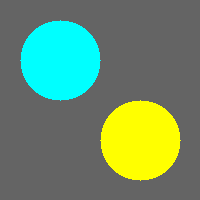


d. цветное -> моно


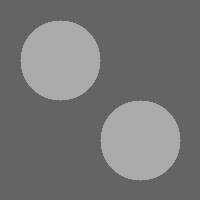


a. моно -> моно (коррекция)


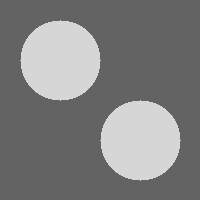


b. цветное -> цветное


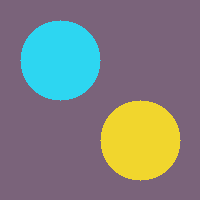


f. моно -> бинарное


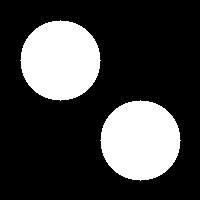


c. бинарное -> бинарное


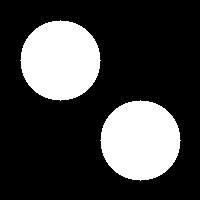


g. бинарное -> моно (dist)


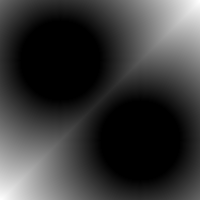


e. моно -> цветное (JET)


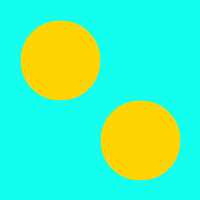


h. цветное -> бинарное


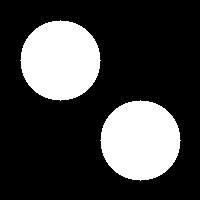


i. бинарное -> цветное


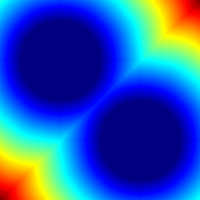

In [23]:
from IPython.display import Image, display

images = [
    ("0. исходное цветное",         "img_0_original.png"),
    ("d. цветное -> моно",          "img_d_color2mono.png"),
    ("a. моно -> моно (коррекция)", "img_a_monofix.png"),
    ("b. цветное -> цветное",       "img_b_colorfix.png"),
    ("f. моно -> бинарное",         "img_f_mono2bin.png"),
    ("c. бинарное -> бинарное",     "img_c_bin2bin.png"),
    ("g. бинарное -> моно (dist)",  "img_g_bin2mono.png"),
    ("e. моно -> цветное (JET)",    "img_e_mono2color.png"),
    ("h. цветное -> бинарное",      "img_h_color2bin.png"),
    ("i. бинарное -> цветное",      "img_i_bin2color.png"),
]

for label, path in images:
    print(label)
    display(Image(path))
    print()